11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


c:\Users\SwaraNafade\Weekly-Plan\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9216 - loss: 0.2664 - val_accuracy: 0.9609 - val_loss: 0.1335
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9666 - loss: 0.1116 - val_accuracy: 0.9672 - val_loss: 0.1138
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9756 - loss: 0.0759 - val_accuracy: 0.9734 - val_loss: 0.0869
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9824 - loss: 0.0577 - val_accuracy: 0.9695 - val_loss: 0.1098
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9862 - loss: 0.0434 - val_accuracy: 0.9732 - val_loss: 0.0994
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9891 - loss: 0.0340 - val_accuracy: 0.9726 - val_loss: 0.0995
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9899 - loss: 0.0290 - val_accuracy: 0.9726 - val_loss: 0.1116
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9918 - loss: 0.0248 - 

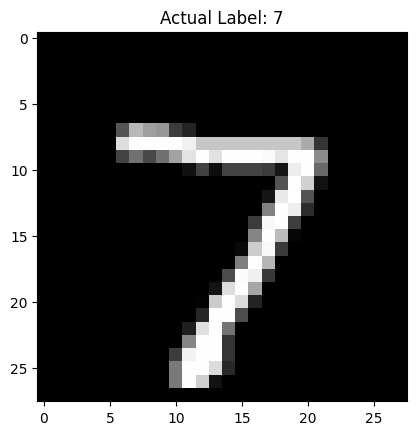

Predicted Digit: 7


In [1]:
# Handwritten Digit Recognition using Keras (MNIST Dataset)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Check shape
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Normalize the data (0-255 -> 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build ANN model
model = Sequential()

# Convert 28x28 image into 1D vector
model.add(Flatten(input_shape=(28, 28)))

# Hidden layers
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# Output layer (10 classes: 0-9)
model.add(Dense(10, activation='softmax'))

# Model summary
model.summary()

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

# Evaluate model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", test_accuracy)

# Predict on test data
predictions = model.predict(X_test)

# Display one test image
plt.imshow(X_test[0], cmap='gray')
plt.title("Actual Label: " + str(y_test[0]))
plt.show()

# Predicted digit
predicted_digit = predictions[0].argmax()

print("Predicted Digit:", predicted_digit)